# Fig 6.18

Model of calcium-induced calcium release in hepatocytes

In [1]:
using Catalyst
using ModelingToolkit
using OrdinaryDiffEq
using Plots
Plots.default(linewidth=2)

In [2]:
rn = @reaction_network begin
    @parameters I(t)
    (k1 * I, km1), R <--> RI
    (k2 * C, km2), RI <--> RIC
    (k3 * C, km3), RIC <--> RICC
    vr * (γ0 + γ1 * RIC) * (Cer - C), 0 --> C
    hill(C, p1, p2, 4), C => 0
end

Model ##ReactionSystem#266:
Unknowns (5): see unknowns(##ReactionSystem#266)
  R(t)
  RI(t)
  RIC(t)
  RICC(t)
  ⋮
Parameters (13): see parameters(##ReactionSystem#266)
  I(t)
  k1
  km1
  k2
  ⋮

In [3]:
setdefaults!(rn, [
    :γ0 => 0.1,
    :γ1 => 20.5,
    :p1 => 8.5,
    :p2 => 0.065,
    :k1 => 12,
    :k2 => 15,
    :k3 => 1.8,
    :km1 => 8,
    :km2 => 1.65,
    :km3 => 0.21,
    :Cer => 8.37,
    :vr => 0.185,
    :I => 0,
    :C => 0,
    :R => 1,
    :RI => 0,
    :RIC => 0,
    :RICC => 0
])

osys = convert(ODESystem, rn; remove_conserved = true) |> structural_simplify
equations(osys)

┌ Warning: You are creating a system or problem while eliminating conserved quantities. Please note,
│         due to limitations / design choices in ModelingToolkit if you use the created system to
│         create a problem (e.g. an `ODEProblem`), or are directly creating a problem, you *should not*
│         modify that problem's initial conditions for species (e.g. using `remake`). Changing initial
│         conditions must be done by creating a new Problem from your reaction system or the
│         ModelingToolkit system you converted it into with the new initial condition map.
│         Modification of parameter values is still possible, *except* for the modification of any
│         conservation law constants (Γ), which is not possible. You might
│         get this warning when creating a problem directly.
│ 
│         You can remove this warning by setting `remove_conserved_warn = false`.
└ @ Catalyst ~/.julia/packages/Catalyst/48wH3/src/reactionsystem_conversions.jl:456


4-element Vector{Symbolics.Equation}:
 Differential(t)(R(t)) ~ km1*RI(t) - k1*R(t)*I(t)
 Differential(t)(RI(t)) ~ -km1*RI(t) + km2*RIC(t) + k1*R(t)*I(t) - k2*RI(t)*C(t)
 Differential(t)(RIC(t)) ~ -km2*RIC(t) + km3*(-R(t) - RI(t) - RIC(t) + Γ[1]) + k2*RI(t)*C(t) - k3*RIC(t)*C(t)
 Differential(t)(C(t)) ~ -Catalyst.hill(C(t), p1, p2, 4) + (Cer - C(t))*vr*(γ0 + RIC(t)*γ1)

## Fig 6.18 (A)

┌ Warning: Initialization system is overdetermined. 1 equations for 0 unknowns. Initialization will default to using least squares. `SCCNonlinearProblem` can only be used for initialization of fully determined systems and hence will not be used here. To suppress this warning pass warn_initialize_determined = false. To make this warning into an error, pass fully_determined = true
└ @ ModelingToolkit ~/.julia/packages/ModelingToolkit/8S2W1/src/systems/diffeqs/abstractodesystem.jl:1441


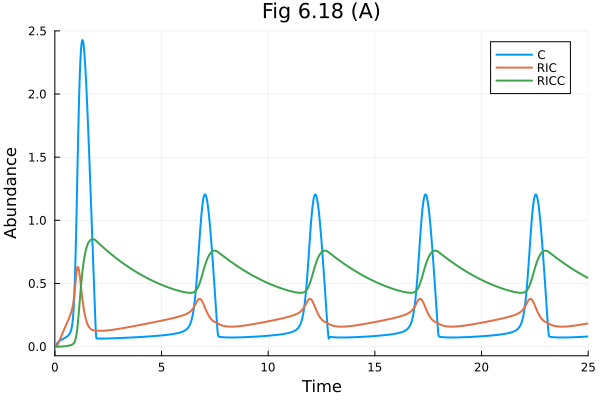

In [4]:
@unpack I = osys
prob = ODEProblem(osys, [], (0., 25.), [I => 2.0])
sol = solve(prob)

@unpack C, RIC, RICC = osys
plot(sol, idxs=[C, RIC, RICC], title="Fig 6.18 (A)", xlabel="Time", ylabel="Abundance", legend=:topright)

## Fig 6.18 (B)

┌ Warning: You are creating a system or problem while eliminating conserved quantities. Please note,
│         due to limitations / design choices in ModelingToolkit if you use the created system to
│         create a problem (e.g. an `ODEProblem`), or are directly creating a problem, you *should not*
│         modify that problem's initial conditions for species (e.g. using `remake`). Changing initial
│         conditions must be done by creating a new Problem from your reaction system or the
│         ModelingToolkit system you converted it into with the new initial condition map.
│         Modification of parameter values is still possible, *except* for the modification of any
│         conservation law constants (Γ), which is not possible. You might
│         get this warning when creating a problem directly.
│ 
│         You can remove this warning by setting `remove_conserved_warn = false`.
└ @ Catalyst ~/.julia/packages/Catalyst/48wH3/src/reactionsystem_conversions.jl:456
┌ Warn

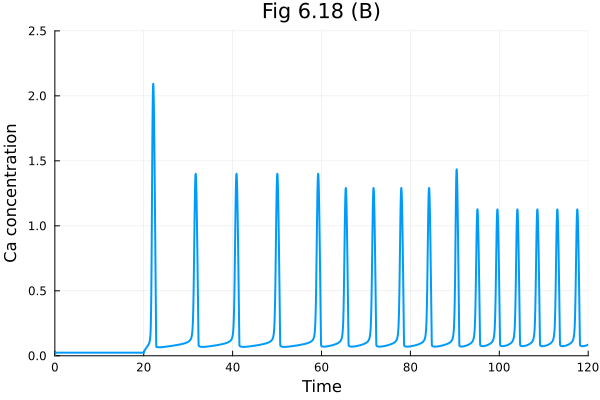

In [5]:
discrete_events = [[20] => [I ~ 0.7], [60] => [I ~ 1.2], [90] => [I ~ 4.0]]
osys618 = convert(ODESystem, rn; discrete_events, remove_conserved = true) |> structural_simplify

tend = 120.
prob = ODEProblem(osys618, [], tend)
sol = solve(prob)

plot(sol, idxs=[osys.C], title="Fig 6.18 (B)", xlabel="Time", ylabel="Ca concentration", legend=false, ylim=(0, 2.5))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*